# Unit11_Decision_Tree_Example01 | 決策樹分類：心臟病風險預測

本 Notebook 使用 `Part_3/Unit11/data/decision_tree/train.csv` 建立 **Decision Tree 分類模型**，以預測患者是否具有心臟病風險。

## 目標
- 載入並探索心臟病臨床特徵資料集（Kaggle）
- 建立三個決策樹模型（無限制 / 手動剪枝 / GridSearchCV 調參）
- 評估模型性能（Accuracy, Confusion Matrix, ROC-AUC）
- 分析特徵重要性，找出關鍵診斷指標
- 可視化決策樹結構，提取可解釋的診斷規則

資料來源：[Heart Disease Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/algozee/heart-decices/data)


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'P3_Unit11_Example01_Heart_Disease'
SOURCE_DATA_DIR = 'decision_tree'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3590'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3590')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    NOTEBOOK_DIR = shortcut_path / 'Part_3' / 'Unit11'
    OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    DATA_DIR = NOTEBOOK_DIR / 'data' / SOURCE_DATA_DIR
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    DATA_DIR = NOTEBOOK_DIR / 'data' / SOURCE_DATA_DIR

MODEL_DIR = OUTPUT_DIR / 'models'
FIG_DIR   = OUTPUT_DIR / 'figs'

for d in [OUTPUT_DIR, DATA_DIR, MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook 工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 數據來源目錄:      {DATA_DIR}")
print(f"✓ 結果輸出目錄:      {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄:      {FIG_DIR}")


✓ 偵測到 Local 環境

✓ Notebook 工作目錄: d:\MyGit\ChemE-3590\Part_3\Unit11
✓ 數據來源目錄:      d:\MyGit\ChemE-3590\Part_3\Unit11\data\decision_tree
✓ 結果輸出目錄:      d:\MyGit\ChemE-3590\Part_3\Unit11\outputs\P3_Unit11_Example01_Heart_Disease
✓ 圖檔輸出目錄:      d:\MyGit\ChemE-3590\Part_3\Unit11\outputs\P3_Unit11_Example01_Heart_Disease\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import (DecisionTreeClassifier, plot_tree, export_text)
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
import joblib

# ── 全域設定 ──────────────────────────────────────────────────────
RANDOM_STATE = 42
SAMPLE_SIZE  = 5000      # 從 630K 中取樣 5000 筆作為教學示範
TEST_SIZE    = 0.30      # 70% 訓練 / 30% 測試

np.random.seed(RANDOM_STATE)
print("✓ 所有套件載入完成")
print(f"  - scikit-learn: OK | numpy: {np.__version__} | pandas: {pd.__version__}")


✓ 所有套件載入完成
  - scikit-learn: OK | numpy: 1.23.5 | pandas: 2.3.3


---
### 2. 資料載入與基本探索

**資料集說明**：心臟病預測臨床資料集
- 來源：Kaggle — [Heart Disease Prediction Using Machine Learning](https://www.kaggle.com/datasets/algozee/heart-decices/data)
- 原始規模：630,000 筆訓練樣本，14 個特徵 + 1 個目標變數
- 教學取樣：隨機抽取 **5,000** 筆用於示範（加速計算）

**特徵說明**：

| 欄位 | 說明 | 類型 |
|------|------|------|
| Age | 患者年齡 | 連續 |
| Sex | 性別 (0=女, 1=男) | 二元 |
| Chest_pain_type | 胸痛類型 (1-4) | 類別 |
| BP | 血壓 (mmHg) | 連續 |
| Cholesterol | 膽固醇 (mg/dl) | 連續 |
| FBS_over_120 | 空腹血糖 > 120 (0/1) | 二元 |
| EKG_results | 心電圖結果 (0/1/2) | 類別 |
| Max_HR | 最大心跳率 | 連續 |
| Exercise_angina | 運動性心絞痛 (0/1) | 二元 |
| ST_depression | ST 段壓低值 | 連續 |
| Slope_of_ST | ST 段斜率 (1/2/3) | 類別 |
| Vessels_fluro | 螢光顯影血管數 (0-3) | 類別 |
| Thallium | 鉈核試驗結果 (3/6/7) | 類別 |
| **Heart_Disease** | **目標：心臟病 (1=有, 0=無)** | 二元 |

In [3]:
# ── 載入資料 ────────────────────────────────────────────────────
train_path = DATA_DIR / 'train.csv'
df_raw = pd.read_csv(train_path)
print(f"原始資料大小: {df_raw.shape[0]:,} 筆 × {df_raw.shape[1]} 欄")

# ── 欄位重新命名（去除空格）────────────────────────────────────
col_rename = {
    'Chest pain type':        'Chest_pain_type',
    'FBS over 120':           'FBS_over_120',
    'EKG results':            'EKG_results',
    'Max HR':                 'Max_HR',
    'Exercise angina':        'Exercise_angina',
    'ST depression':          'ST_depression',
    'Slope of ST':            'Slope_of_ST',
    'Number of vessels fluro':'Vessels_fluro',
    'Heart Disease':          'Heart_Disease',
}
df_raw = df_raw.rename(columns=col_rename).drop(columns=['id'])

# ── 取樣 5000 筆（分層取樣，保持類別比例）───────────────────
df = df_raw.groupby('Heart_Disease', group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_SIZE / len(df_raw), random_state=RANDOM_STATE)
).reset_index(drop=True)
print(f"取樣後資料大小: {df.shape[0]} 筆 × {df.shape[1]} 欄\n")

# ── 基本資訊 ────────────────────────────────────────────────────
print("=== 資料型態 ===")
print(df.dtypes.to_string())
print(f"\n=== 缺失值 ===")
print(df.isnull().sum().to_string())


原始資料大小: 630,000 筆 × 15 欄
取樣後資料大小: 5000 筆 × 14 欄

=== 資料型態 ===
Age                  int64
Sex                  int64
Chest_pain_type      int64
BP                   int64
Cholesterol          int64
FBS_over_120         int64
EKG_results          int64
Max_HR               int64
Exercise_angina      int64
ST_depression      float64
Slope_of_ST          int64
Vessels_fluro        int64
Thallium             int64
Heart_Disease       object

=== 缺失值 ===
Age                0
Sex                0
Chest_pain_type    0
BP                 0
Cholesterol        0
FBS_over_120       0
EKG_results        0
Max_HR             0
Exercise_angina    0
ST_depression      0
Slope_of_ST        0
Vessels_fluro      0
Thallium           0
Heart_Disease      0


In [4]:
# ── 統計摘要 ────────────────────────────────────────────────────
print("=== 基本統計 ===")
display(df.describe().round(2))

# ── 目標變數分佈 ─────────────────────────────────────────────
print("\n=== 目標變數分佈 ===")
vc = df['Heart_Disease'].value_counts()
print(vc.to_string())
print(f"Presence 比例: {vc['Presence']/len(df)*100:.1f}%")
print(f"Absence  比例: {vc['Absence'] /len(df)*100:.1f}%")


=== 基本統計 ===


,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Vessels_fluro,Thallium
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,54.14,0.72,3.34,130.59,244.30,0.08,0.98,152.68,0.28,0.72,1.45,0.45,4.62
std,8.17,0.45,0.83,14.85,34.17,0.28,1.00,19.48,0.45,0.95,0.55,0.80,1.95
min,29.00,0.00,1.00,94.00,149.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,219.00,0.00,0.00,142.00,0.00,0.00,1.00,0.00,3.00
50%,54.00,1.00,4.00,130.00,243.00,0.00,0.00,157.00,0.00,0.05,1.00,0.00,3.00
75%,60.00,1.00,4.00,140.00,269.00,0.00,2.00,168.00,1.00,1.40,2.00,1.00,7.00
max,77.00,1.00,4.00,192.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00



=== 目標變數分佈 ===
Heart_Disease
Absence     2758
Presence    2242
Presence 比例: 44.8%
Absence  比例: 55.2%


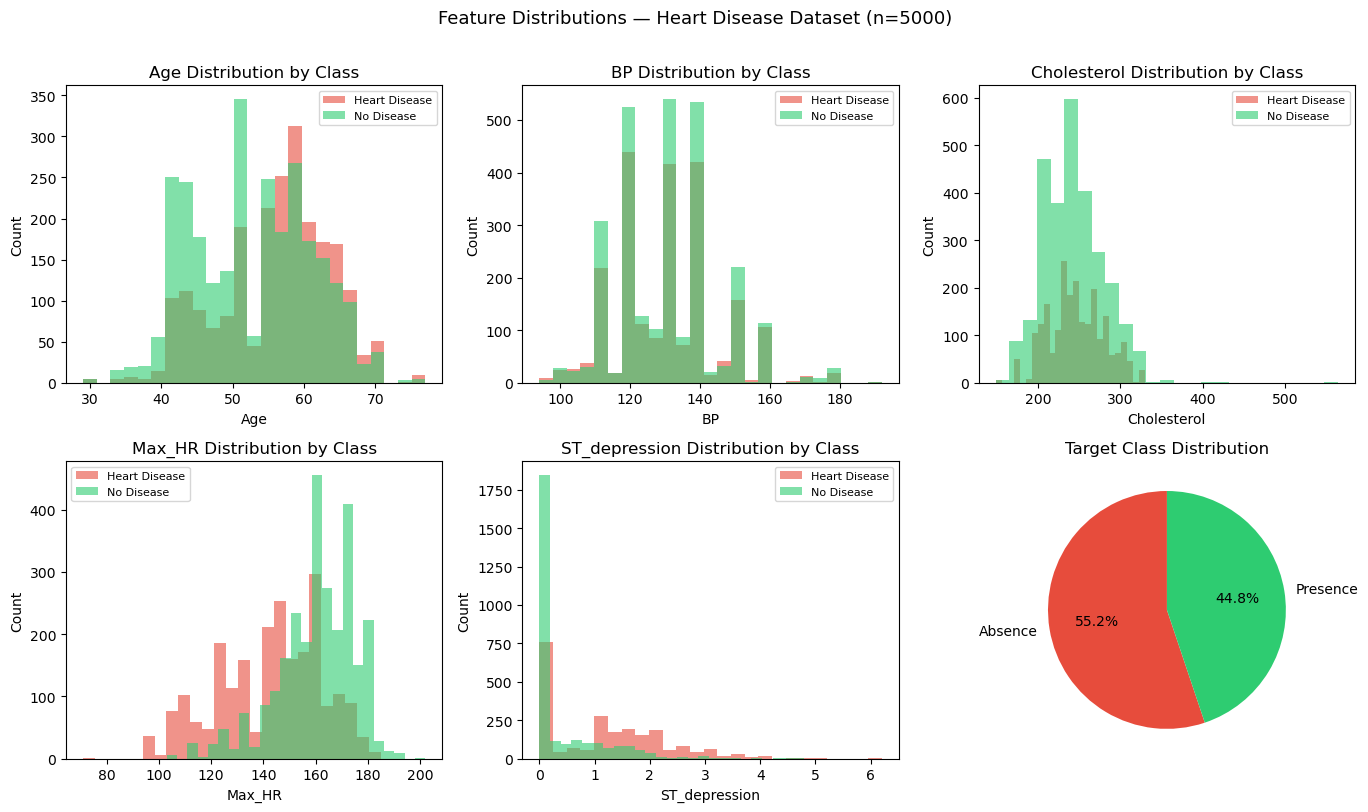

✓ 圖1 儲存完成


In [5]:
# ── 圖1：特徵分佈（連續特徵直方圖）─────────────────────────
cont_features = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(cont_features):
    for cls, color, lbl in [('Presence', '#e74c3c', 'Heart Disease'),
                             ('Absence',  '#2ecc71', 'No Disease')]:
        subset = df[df['Heart_Disease'] == cls][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=lbl)
    axes[i].set_title(f'{feat} Distribution by Class')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# 最後一格：目標類別圓餅圖
vc = df['Heart_Disease'].value_counts()
axes[5].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[5].set_title('Target Class Distribution')

plt.suptitle('Feature Distributions — Heart Disease Dataset (n=5000)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / '01_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ 圖1 儲存完成")


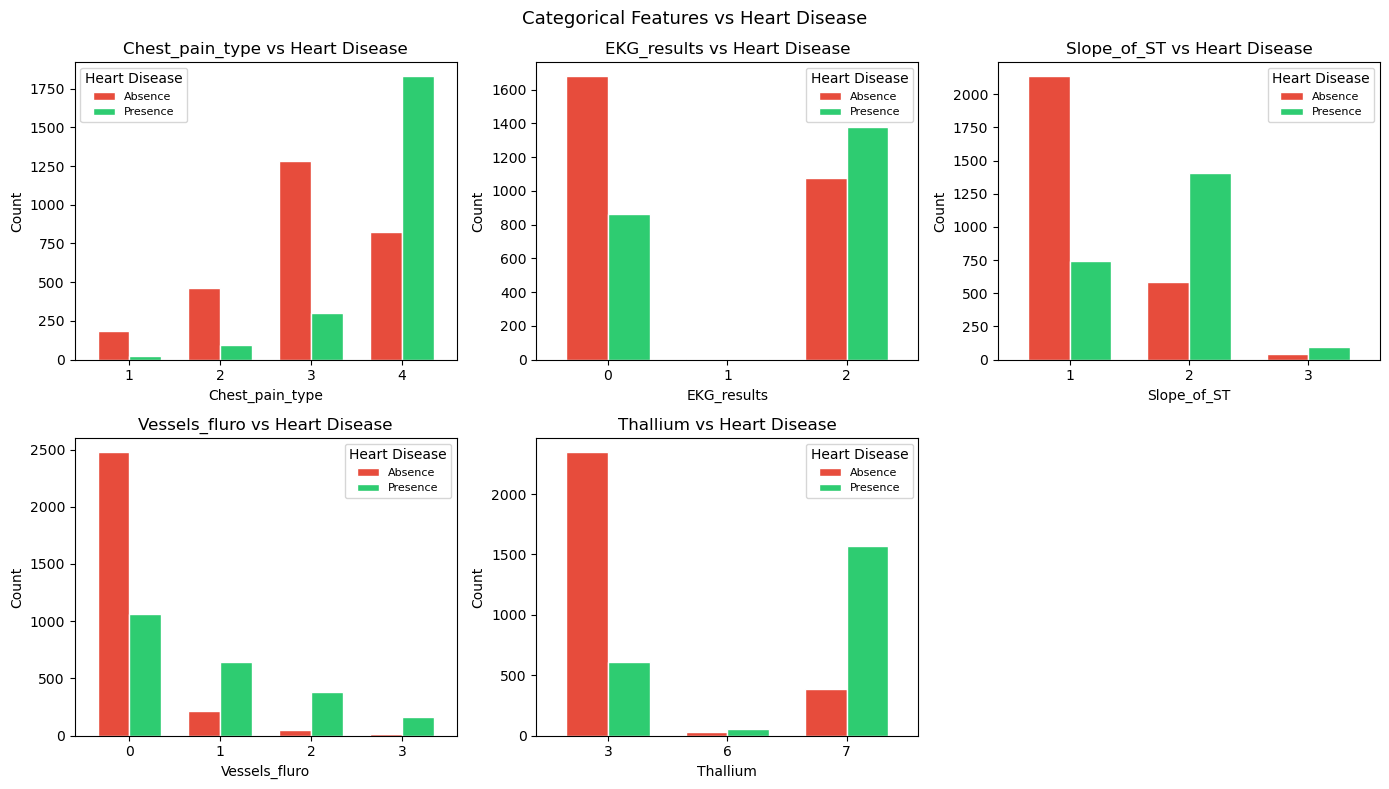

✓ 圖2 儲存完成


In [6]:
# ── 圖2：類別特徵 vs 心臟病（Grouped Bar）───────────────────
cat_features = ['Chest_pain_type', 'EKG_results', 'Slope_of_ST',
                'Vessels_fluro', 'Thallium']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = df.groupby([feat, 'Heart_Disease']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'{feat} vs Heart Disease')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Heart Disease', fontsize=8)

axes[5].axis('off')
plt.suptitle('Categorical Features vs Heart Disease', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '02_categorical_features.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ 圖2 儲存完成")


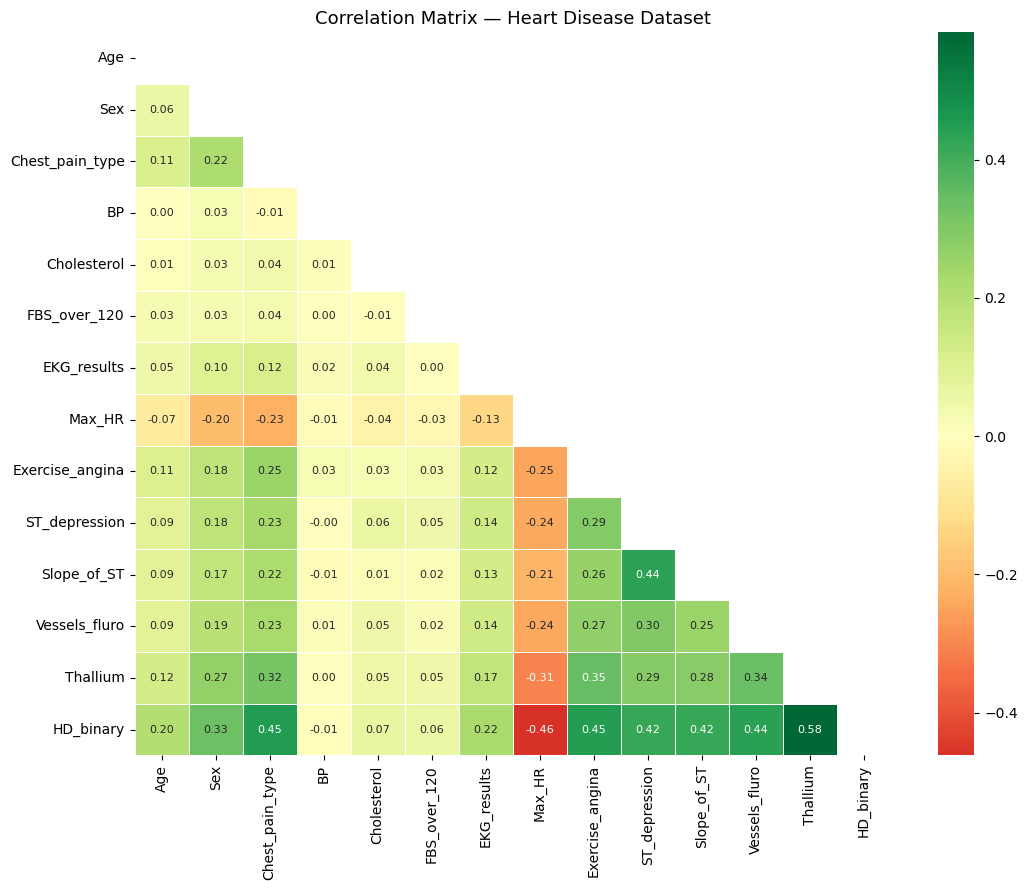

✓ 圖3 儲存完成

與目標變數 HD_binary 相關性（絕對值排序）：
Thallium           0.584
Max_HR             0.462
Chest_pain_type    0.452
Exercise_angina    0.448
Vessels_fluro      0.440
Slope_of_ST        0.424
ST_depression      0.422
Sex                0.335
EKG_results        0.223
Age                0.202
Cholesterol        0.067
FBS_over_120       0.057
BP                 0.005


In [7]:
# ── 圖3：相關性熱力圖 ───────────────────────────────────────
df_corr = df.copy()
df_corr['HD_binary'] = (df_corr['Heart_Disease'] == 'Presence').astype(int)
df_corr = df_corr.drop(columns=['Heart_Disease'])

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Heart Disease Dataset', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ 圖3 儲存完成")
print("\n與目標變數 HD_binary 相關性（絕對值排序）：")
print(corr['HD_binary'].drop('HD_binary').abs().sort_values(ascending=False).round(3).to_string())


---
### 3. 資料預處理

**處理步驟**：
1. 將目標變數 `Heart_Disease` 編碼為數值：`Presence → 1`、`Absence → 0`
2. 分離特徵矩陣 $X$ 與目標向量 $y$
3. 以 70/30 分層切割訓練集與測試集（`stratify=y` 保持類別比例）

In [8]:
# ── 目標編碼 ─────────────────────────────────────────────────
df['HD_binary'] = (df['Heart_Disease'] == 'Presence').astype(int)

FEATURE_NAMES = ['Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol',
                 'FBS_over_120', 'EKG_results', 'Max_HR', 'Exercise_angina',
                 'ST_depression', 'Slope_of_ST', 'Vessels_fluro', 'Thallium']

X = df[FEATURE_NAMES].values
y = df['HD_binary'].values

print(f"特徵矩陣 X: {X.shape}")
print(f"目標向量 y: {y.shape}")
print(f"\n目標分佈: 心臟病(1)={y.sum()} ({y.mean()*100:.1f}%)  "
      f"正常(0)={(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# ── 資料切割 ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"\n訓練集: {len(X_train)} 筆  |  測試集: {len(X_test)} 筆")
print(f"訓練集正例比例: {y_train.mean()*100:.1f}%")
print(f"測試集正例比例: {y_test.mean()*100:.1f}%")


特徵矩陣 X: (5000, 13)
目標向量 y: (5000,)

目標分佈: 心臟病(1)=2242 (44.8%)  正常(0)=2758 (55.2%)

訓練集: 3500 筆  |  測試集: 1500 筆
訓練集正例比例: 44.8%
測試集正例比例: 44.9%


---
### 4. 建立決策樹分類模型

**分裂準則 — Gini 不純度**：

$$
\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2
$$

其中 $p_k$ 為節點 $t$ 中第 $k$ 類的比例。Gini 值越小代表節點越純。

**最優分裂選擇**：

$$
(j^*, s^*) = \arg\min_{j,s} \left[ \frac{N_L}{N} \cdot \text{Gini}(L) + \frac{N_R}{N} \cdot \text{Gini}(R) \right]
$$

#### 4.1 Model A：無限制樹（過擬合基準）

In [9]:
# Model A：無限制樹（max_depth=None）
tree_A = DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE)
tree_A.fit(X_train, y_train)

acc_A_train = accuracy_score(y_train, tree_A.predict(X_train))
acc_A_test  = accuracy_score(y_test,  tree_A.predict(X_test))

print("=== Model A：無限制樹 ===")
print(f"樹深度: {tree_A.get_depth()}  |  葉節點數: {tree_A.get_n_leaves()}")
print(f"訓練集 Accuracy: {acc_A_train:.4f}")
print(f"測試集 Accuracy: {acc_A_test:.4f}")
print(f"過擬合差距:      {acc_A_train - acc_A_test:.4f}")


=== Model A：無限制樹 ===
樹深度: 19  |  葉節點數: 475
訓練集 Accuracy: 1.0000
測試集 Accuracy: 0.8073
過擬合差距:      0.1927


#### 4.2 Model B：手動剪枝（max_depth=4）

In [10]:
# Model B：手動剪枝
tree_B = DecisionTreeClassifier(criterion='gini', max_depth=4,
                                 min_samples_leaf=10, random_state=RANDOM_STATE)
tree_B.fit(X_train, y_train)

acc_B_train = accuracy_score(y_train, tree_B.predict(X_train))
acc_B_test  = accuracy_score(y_test,  tree_B.predict(X_test))

print("=== Model B：手動剪枝 (depth=4) ===")
print(f"樹深度: {tree_B.get_depth()}  |  葉節點數: {tree_B.get_n_leaves()}")
print(f"訓練集 Accuracy: {acc_B_train:.4f}")
print(f"測試集 Accuracy: {acc_B_test:.4f}")
print(f"過擬合差距:      {acc_B_train - acc_B_test:.4f}")

# ── 比較表格 ─────────────────────────────────────────────────
print("\n{'='*52}")
print(f"{'模型':<15} {'深度':>5} {'葉數':>6} {'訓練Acc':>10} {'測試Acc':>10}")
print('-'*52)
for name, tree, atr, ate in [
    ('Model A (無限制)', tree_A, acc_A_train, acc_A_test),
    ('Model B (depth=4)', tree_B, acc_B_train, acc_B_test),
]:
    print(f"{name:<15} {tree.get_depth():>5} {tree.get_n_leaves():>6} {atr:>10.4f} {ate:>10.4f}")


=== Model B：手動剪枝 (depth=4) ===
樹深度: 4  |  葉節點數: 16
訓練集 Accuracy: 0.8500
測試集 Accuracy: 0.8480
過擬合差距:      0.0020

{'='*52}
模型                 深度     葉數      訓練Acc      測試Acc
----------------------------------------------------
Model A (無限制)      19    475     1.0000     0.8073
Model B (depth=4)     4     16     0.8500     0.8480


---
### 5. 超參數調整（GridSearchCV）

使用 **5 折交叉驗證**搜尋最佳超參數組合：

| 超參數 | 搜尋範圍 | 意義 |
|--------|---------|------|
| `max_depth` | [3, 5, 7, 10] | 樹的最大深度 |
| `min_samples_split` | [2, 10, 20] | 內部節點最小分裂樣本數 |
| `min_samples_leaf` | [1, 5, 10] | 葉節點最小樣本數 |
| `criterion` | ['gini', 'entropy'] | 分裂準則 |

搜尋空間：$4 \times 3 \times 3 \times 2 = 72$ 組合，共 $72 \times 5 = 360$ 次 CV 擬合

In [11]:
param_grid = {
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf':  [1, 5, 10],
    'criterion':         ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
print("=== GridSearchCV 結果 ===")
print(f"最佳超參數: {grid_search.best_params_}")
print(f"CV 平均 Accuracy: {grid_search.best_score_:.4f}")
print(f"樹深度: {best_tree.get_depth()}  |  葉節點數: {best_tree.get_n_leaves()}")


=== GridSearchCV 結果 ===
最佳超參數: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
CV 平均 Accuracy: 0.8443
樹深度: 5  |  葉節點數: 31


---
### 6. 最佳模型評估

In [12]:
y_pred_best = best_tree.predict(X_test)
y_prob_best = best_tree.predict_proba(X_test)[:, 1]

acc_best_train = accuracy_score(y_train, best_tree.predict(X_train))
acc_best_test  = accuracy_score(y_test,  y_pred_best)
auc_best       = roc_auc_score(y_test, y_prob_best)

print("=== 最佳模型（GridSearchCV）完整評估 ===")
print(f"訓練集 Accuracy: {acc_best_train:.4f}")
print(f"測試集 Accuracy: {acc_best_test:.4f}")
print(f"測試集 ROC-AUC:  {auc_best:.4f}")
print(f"過擬合差距:      {acc_best_train - acc_best_test:.4f}")
print()
print("分類報告：")
print(classification_report(y_test, y_pred_best,
                              target_names=['No Disease (0)', 'Heart Disease (1)']))

# ── 三模型彙整 ───────────────────────────────────────────────
print("\n=== 三模型比較 ===")
print(f"{'模型':<22} {'深度':>5} {'葉數':>6} {'訓練Acc':>10} {'測試Acc':>10}")
print('-'*58)
for name, tree, atr, ate in [
    ('Model A (無限制)',     tree_A,    acc_A_train,    acc_A_test),
    ('Model B (depth=4)',   tree_B,    acc_B_train,    acc_B_test),
    ('Best (GridSearch)',   best_tree, acc_best_train, acc_best_test),
]:
    print(f"{name:<22} {tree.get_depth():>5} {tree.get_n_leaves():>6} {atr:>10.4f} {ate:>10.4f}")


=== 最佳模型（GridSearchCV）完整評估 ===
訓練集 Accuracy: 0.8643
測試集 Accuracy: 0.8513
測試集 ROC-AUC:  0.9228
過擬合差距:      0.0130

分類報告：
                   precision    recall  f1-score   support

   No Disease (0)       0.85      0.88      0.87       827
Heart Disease (1)       0.85      0.82      0.83       673

         accuracy                           0.85      1500
        macro avg       0.85      0.85      0.85      1500
     weighted avg       0.85      0.85      0.85      1500


=== 三模型比較 ===
模型                        深度     葉數      訓練Acc      測試Acc
----------------------------------------------------------
Model A (無限制)             19    475     1.0000     0.8073
Model B (depth=4)          4     16     0.8500     0.8480
Best (GridSearch)          5     31     0.8643     0.8513


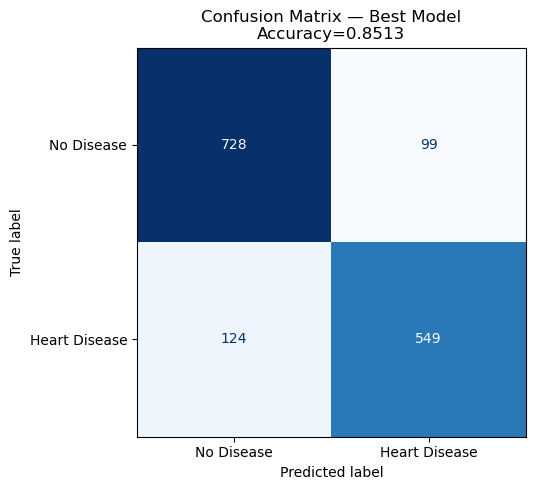

True Negative  (TN): 728  — 正確預測無病
False Positive (FP): 99  — 誤報有病（假陽性）
False Negative (FN): 124  — 漏診有病（假陰性）★重要！
True Positive  (TP): 549  — 正確預測有病
Sensitivity (Recall): 0.8158  Specificity: 0.8803
✓ 圖4 儲存完成


In [13]:
# ── 圖4：混淆矩陣 ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Confusion Matrix — Best Model\nAccuracy={acc_best_test:.4f}', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / '04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN): {tn}  — 正確預測無病")
print(f"False Positive (FP): {fp}  — 誤報有病（假陽性）")
print(f"False Negative (FN): {fn}  — 漏診有病（假陰性）★重要！")
print(f"True Positive  (TP): {tp}  — 正確預測有病")
print(f"Sensitivity (Recall): {tp/(tp+fn):.4f}  Specificity: {tn/(tn+fp):.4f}")
print("✓ 圖4 儲存完成")


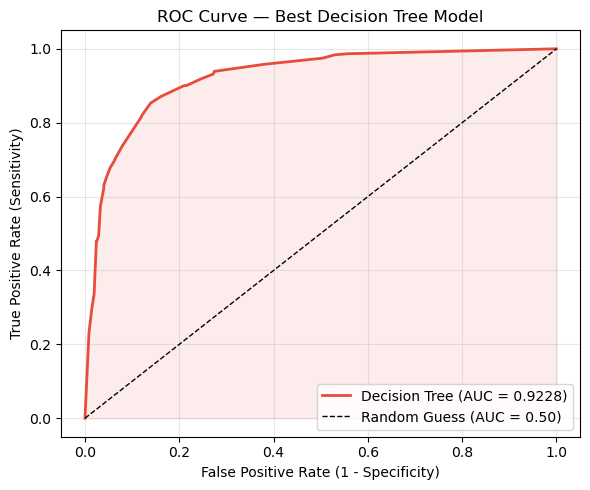

✓ 圖5 儲存完成  |  AUC = 0.9228


In [14]:
# ── 圖5：ROC 曲線 ────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Decision Tree (AUC = {auc_best:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Best Decision Tree Model')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / '05_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖5 儲存完成  |  AUC = {auc_best:.4f}")


---
#### 6.4 閾值調整（Threshold Tuning）— 降低漏診（FN）

決策樹的預設分類閾值為 **0.5**，即當患心臟病機率 ≥ 0.5 時預測為陽性。
降低閾值可提高**敏感度（Sensitivity）**，代價是**特異度（Specificity）下降**，即更多假陽性。

$$
\text{Threshold} \downarrow \;\Rightarrow\; \text{Sensitivity} \uparrow \;(\text{FN} \downarrow) \;,\quad \text{Specificity} \downarrow \;(\text{FP} \uparrow)
$$

> 在醫療篩查情境中，通常優先降低 FN（漏診），即選擇較低閾值。


         Threshold  Sensitivity  Specificity   Accuracy     FN     FP
------------------------------------------------------------------
    0.50 (predict)       0.8158       0.8803     0.8513    124     99  ← 預設
              0.45       0.8529       0.8609     0.8573     99    115
               0.4       0.8707       0.8392     0.8533     87    133
              0.35       0.9004       0.7896     0.8393     67    174
               0.3       0.9316       0.7279     0.8193     46    225


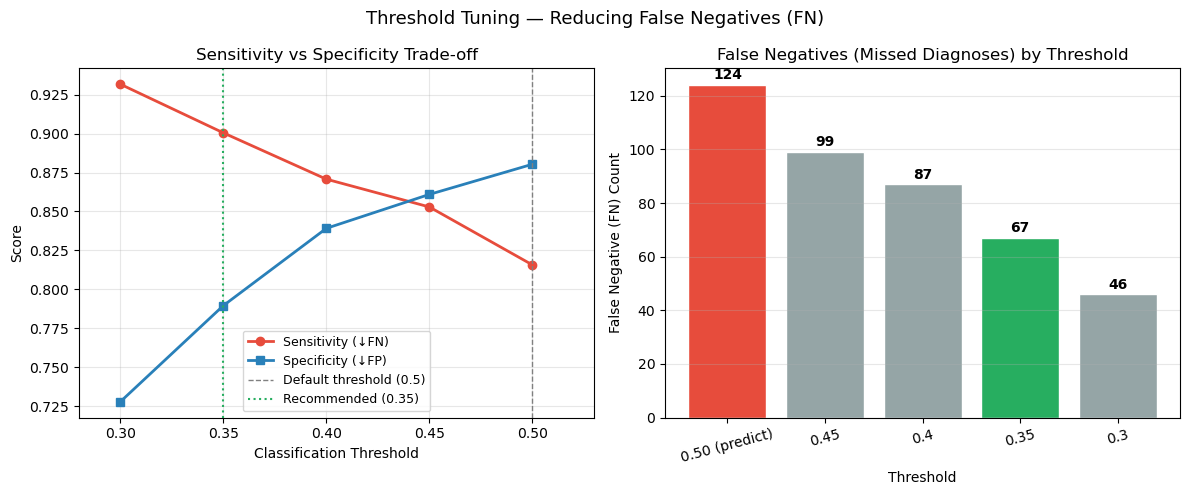


=== 閾值調整至 0.35 的完整評估 ===
                   precision    recall  f1-score   support

   No Disease (0)       0.91      0.79      0.84       827
Heart Disease (1)       0.78      0.90      0.83       673

         accuracy                           0.84      1500
        macro avg       0.84      0.85      0.84      1500
     weighted avg       0.85      0.84      0.84      1500

FN 從 124 降至 67（減少 57 筆漏診，46.0%↓）
FP 從 99 增至 174（增加 75 筆誤報）
Sensitivity: 0.9004  Specificity: 0.7896
✓ 圖5b 儲存完成


In [22]:
# ── 閾值調整：逐閾值掃描 Sensitivity / Specificity ─────────────
# 注意：threshold=0.50 使用 predict()（argmax 規則）作為基準，
#       與混淆矩陣 Cell 保持一致；其餘閾值用 predict_proba >= thresh。

other_thresholds = [0.45, 0.40, 0.35, 0.30]
results_thresh = []

# ── 基準列：使用 predict()，與混淆矩陣一致 ────────────────────
cm_def = confusion_matrix(y_test, y_pred_best)
tn_d, fp_d, fn_d, tp_d = cm_def.ravel()
results_thresh.append({
    'thresh': 0.50, 'label': '0.50 (predict)',
    'sens': tp_d/(tp_d+fn_d), 'spec': tn_d/(tn_d+fp_d),
    'acc': accuracy_score(y_test, y_pred_best),
    'fn': int(fn_d), 'fp': int(fp_d)
})

# ── 其他閾值：使用 predict_proba >= thresh ─────────────────────
for thresh in other_thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'thresh': thresh, 'label': str(thresh),
        'sens': tp_t/(tp_t+fn_t), 'spec': tn_t/(tn_t+fp_t),
        'acc': accuracy_score(y_test, y_pred_t),
        'fn': int(fn_t), 'fp': int(fp_t)
    })

print(f"{'Threshold':>18} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10} {'FN':>6} {'FP':>6}")
print('-' * 66)
for r in results_thresh:
    marker = '  ← 預設' if r['thresh'] == 0.50 else ''
    print(f"{r['label']:>18} {r['sens']:>12.4f} {r['spec']:>12.4f} {r['acc']:>10.4f} {r['fn']:>6} {r['fp']:>6}{marker}")

# ── 圖5b：Sensitivity-Specificity 權衡圖 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

thresh_labels = [r['label'] for r in results_thresh]
sens_vals     = [r['sens']  for r in results_thresh]
spec_vals     = [r['spec']  for r in results_thresh]
fn_vals       = [r['fn']    for r in results_thresh]
thresh_nums   = [r['thresh'] for r in results_thresh]

ax = axes[0]
ax.plot(thresh_nums, sens_vals, 'o-', color='#e74c3c', lw=2, label='Sensitivity (↓FN)')
ax.plot(thresh_nums, spec_vals, 's-', color='#2980b9', lw=2, label='Specificity (↓FP)')
ax.axvline(0.50, color='gray',    ls='--', lw=1,   label='Default threshold (0.5)')
ax.axvline(0.35, color='#27ae60', ls=':',  lw=1.5, label='Recommended (0.35)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity vs Specificity Trade-off')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0.28, 0.53)

ax2 = axes[1]
colors_bar = ['#e74c3c' if r['thresh'] == 0.50 else
              '#27ae60' if r['thresh'] == 0.35 else '#95a5a6'
              for r in results_thresh]
bars = ax2.bar(thresh_labels, fn_vals, color=colors_bar, edgecolor='white')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('False Negative (FN) Count')
ax2.set_title('False Negatives (Missed Diagnoses) by Threshold')
for bar, val in zip(bars, fn_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Threshold Tuning — Reducing False Negatives (FN)', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '05b_threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 閾值 0.35 的詳細報告 ──────────────────────────────────────
BEST_THRESH = 0.35
y_pred_35 = (y_prob_best >= BEST_THRESH).astype(int)
print(f"\n=== 閾值調整至 {BEST_THRESH} 的完整評估 ===")
print(classification_report(y_test, y_pred_35,
                             target_names=['No Disease (0)', 'Heart Disease (1)']))
cm_35 = confusion_matrix(y_test, y_pred_35)
tn35, fp35, fn35, tp35 = cm_35.ravel()
base_fn = results_thresh[0]['fn']   # 124（predict 基準）
base_fp = results_thresh[0]['fp']   # 99（predict 基準）
print(f"FN 從 {base_fn} 降至 {fn35}（減少 {base_fn - fn35} 筆漏診，{(base_fn - fn35)/base_fn*100:.1f}%↓）")
print(f"FP 從 {base_fp} 增至 {fp35}（增加 {fp35 - base_fp} 筆誤報）")
print(f"Sensitivity: {tp35/(tp35+fn35):.4f}  Specificity: {tn35/(tn35+fp35):.4f}")
print(f"✓ 圖5b 儲存完成")


---
### 7. 特徵重要性分析

特徵重要性定義為該特徵在所有節點中貢獻的**加權 Gini 下降量**（已歸一化至總和為 1）：

$$
\text{Importance}_{\text{norm}}(j) = \frac{\sum_{t:\, j^*(t)=j} \frac{N_t}{N} \cdot \Delta \text{Gini}(t)}{\sum_{j'} \sum_{t:\, j^*(t)=j'} \frac{N_t}{N} \cdot \Delta \text{Gini}(t)}
$$

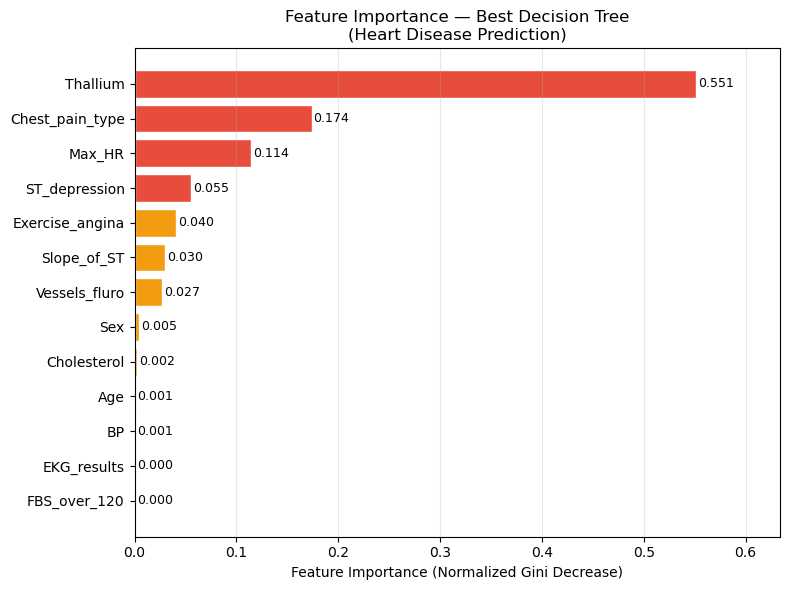

=== 特徵重要性排序 ===
        Feature  Importance
       Thallium    0.551193
Chest_pain_type    0.173800
         Max_HR    0.114291
  ST_depression    0.055296
Exercise_angina    0.040296
    Slope_of_ST    0.029702
  Vessels_fluro    0.026683
            Sex    0.004710
    Cholesterol    0.002433
            Age    0.000904
             BP    0.000692
   FBS_over_120    0.000000
    EKG_results    0.000000

✓ 圖6 + feature_importance.csv 儲存完成


In [15]:
# ── 圖6：特徵重要性 ──────────────────────────────────────────
importances = best_tree.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v >= feat_imp.quantile(0.67) else
          '#f39c12' if v >= feat_imp.quantile(0.33) else '#95a5a6'
          for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Normalized Gini Decrease)')
ax.set_title('Feature Importance — Best Decision Tree\n(Heart Disease Prediction)')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, feat_imp.values.max() * 1.15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / '06_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# 儲存特徵重要性 CSV
feat_imp_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=False)
feat_imp_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print("=== 特徵重要性排序 ===")
print(feat_imp_df.to_string(index=False))
print("\n✓ 圖6 + feature_importance.csv 儲存完成")


---
### 8. 決策樹可視化

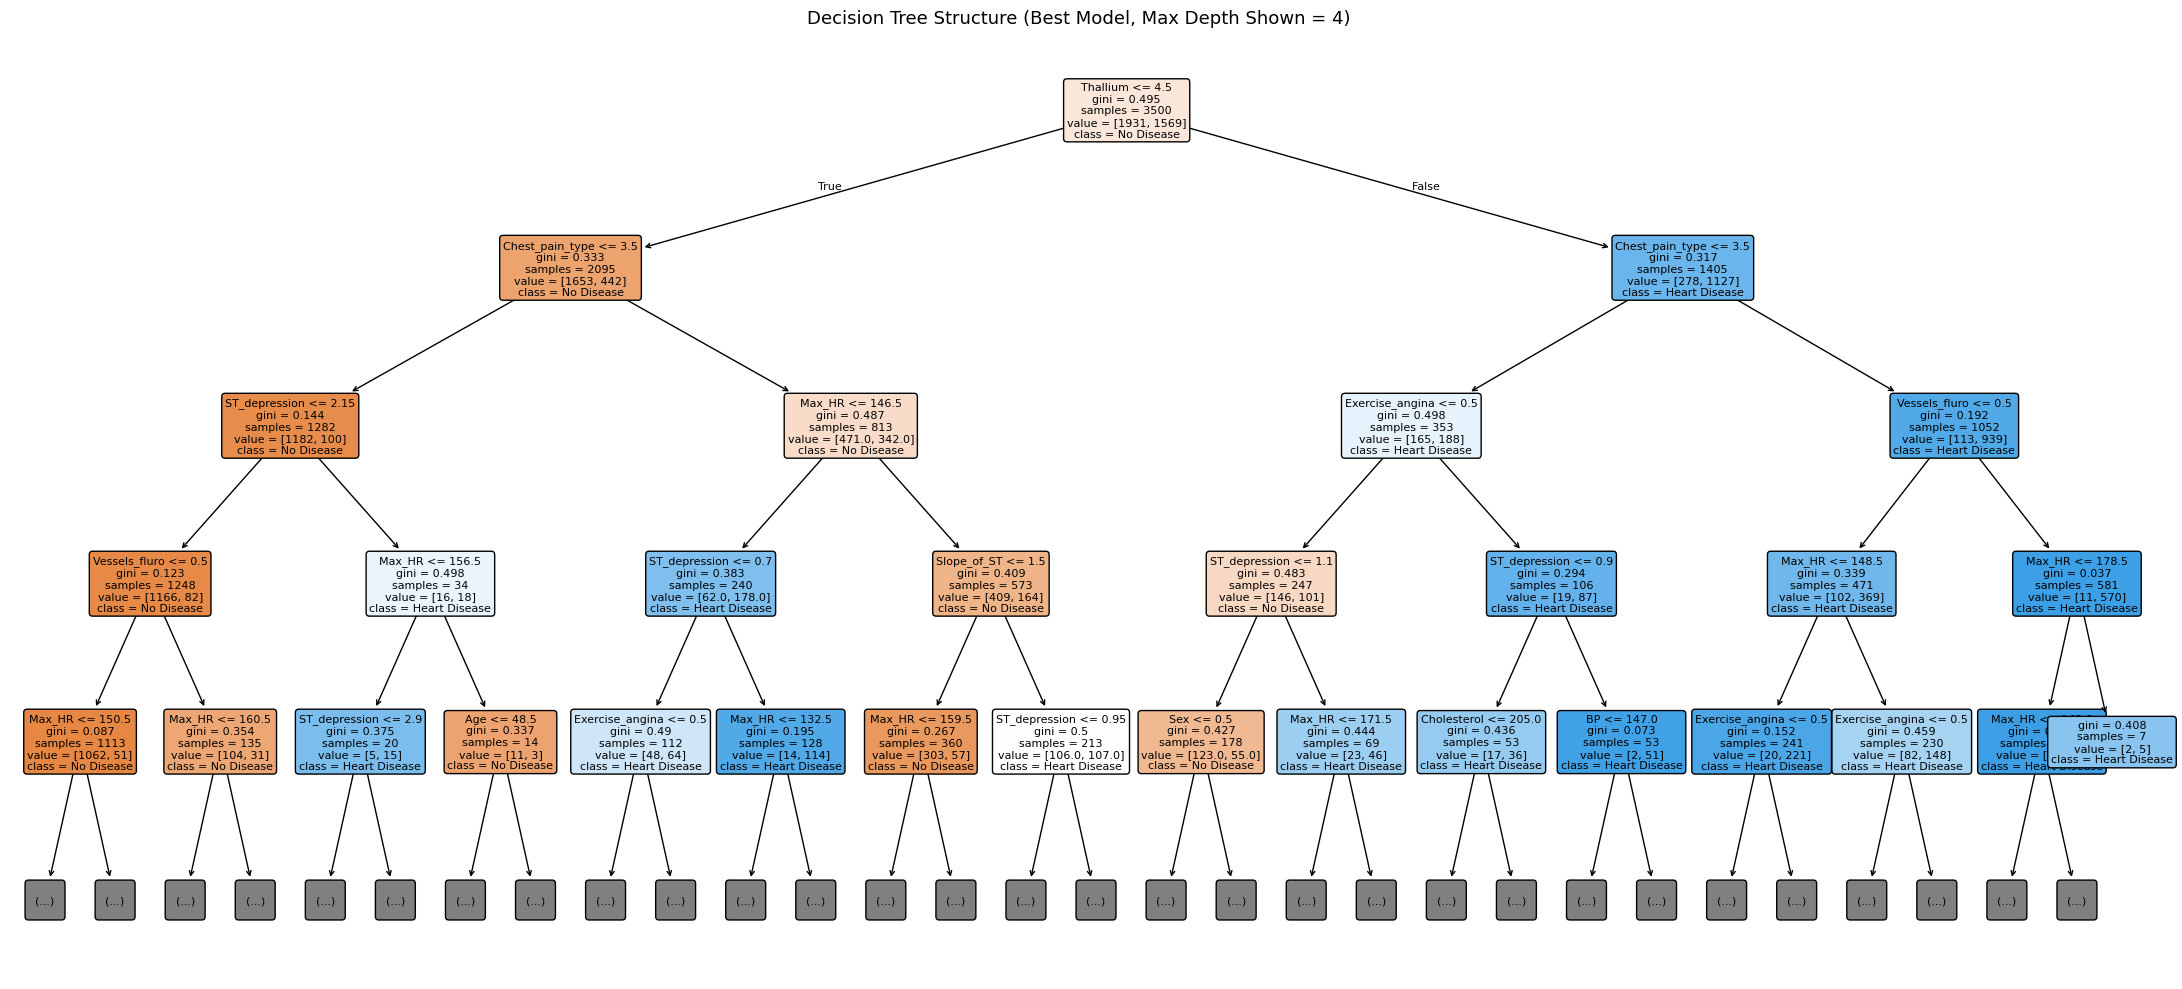

✓ 圖7 儲存完成  (實際樹深=5, 此圖顯示前4層)


In [16]:
# ── 圖7：決策樹結構（顯示前 4 層）────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(best_tree, feature_names=FEATURE_NAMES,
          class_names=['No Disease', 'Heart Disease'],
          filled=True, rounded=True, max_depth=4,
          fontsize=8, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Decision Tree Structure (Best Model, Max Depth Shown = 4)', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '07_tree_structure.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ 圖7 儲存完成  (實際樹深={best_tree.get_depth()}, 此圖顯示前4層)")


---
### 9. 決策規則提取

In [17]:
# ── 提取文字規則並儲存 ───────────────────────────────────────
rules_text = export_text(best_tree, feature_names=FEATURE_NAMES)
rules_path = OUTPUT_DIR / 'tree_rules.txt'
with open(rules_path, 'w', encoding='utf-8') as f:
    f.write(f"Decision Tree Rules — Heart Disease Prediction\n")
    f.write(f"Best Params: {grid_search.best_params_}\n")
    f.write(f"Tree Depth: {best_tree.get_depth()}  |  Leaf Nodes: {best_tree.get_n_leaves()}\n")
    f.write(f"Test Accuracy: {acc_best_test:.4f}  |  AUC: {auc_best:.4f}\n")
    f.write("="*60 + "\n")
    f.write(rules_text)

# 只印前 60 行（避免過長）
lines = rules_text.split('\n')
print(f"決策規則總行數: {len(lines)}\n")
print("--- 前 60 行規則預覽 ---")
print('\n'.join(lines[:60]))
print(f"\n✓ 完整規則已儲存至: {rules_path}")


決策規則總行數: 92

--- 前 60 行規則預覽 ---
|--- Thallium <= 4.50
|   |--- Chest_pain_type <= 3.50
|   |   |--- ST_depression <= 2.15
|   |   |   |--- Vessels_fluro <= 0.50
|   |   |   |   |--- Max_HR <= 150.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Max_HR >  150.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Vessels_fluro >  0.50
|   |   |   |   |--- Max_HR <= 160.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Max_HR >  160.50
|   |   |   |   |   |--- class: 0
|   |   |--- ST_depression >  2.15
|   |   |   |--- Max_HR <= 156.50
|   |   |   |   |--- ST_depression <= 2.90
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ST_depression >  2.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- Max_HR >  156.50
|   |   |   |   |--- Age <= 48.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  48.50
|   |   |   |   |   |--- class: 0
|   |--- Chest_pain_type >  3.50
|   |   |--- Max_HR <= 146.50
|   |   |   |--- ST_depression <= 0.70
|   |   |   |   |

---
### 10. 新患者預測

輸入五位虛構患者的臨床數據，使用最佳模型進行心臟病風險預測：

| 患者 | Age | Sex | Chest_pain | BP | Cholesterol | FBS | EKG | MaxHR | Ex_angina | ST_dep | Slope_ST | Vessels | Thallium |
|------|-----|-----|-----------|-----|-------------|-----|-----|-------|-----------|--------|----------|---------|---------|
| P1（高風險） | 63 | 1 | 4 | 145 | 233 | 1 | 2 | 150 | 0 | 2.3 | 3 | 0 | 6 |
| P2（低風險） | 35 | 0 | 2 | 118 | 195 | 0 | 0 | 182 | 0 | 0.0 | 1 | 0 | 3 |
| P3（中風險） | 56 | 1 | 3 | 130 | 256 | 1 | 2 | 142 | 1 | 0.6 | 2 | 1 | 7 |
| P4（年輕男性）| 45 | 1 | 4 | 140 | 280 | 0 | 0 | 130 | 1 | 3.0 | 2 | 2 | 7 |
| P5（健康女性）| 48 | 0 | 1 | 110 | 220 | 0 | 0 | 165 | 0 | 0.0 | 1 | 0 | 3 |

In [18]:
# 新患者數據
new_patients = pd.DataFrame([
    [63, 1, 4, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],  # P1 高風險
    [35, 0, 2, 118, 195, 0, 0, 182, 0, 0.0, 1, 0, 3],  # P2 低風險
    [56, 1, 3, 130, 256, 1, 2, 142, 1, 0.6, 2, 1, 7],  # P3 中風險
    [45, 1, 4, 140, 280, 0, 0, 130, 1, 3.0, 2, 2, 7],  # P4 年輕男性
    [48, 0, 1, 110, 220, 0, 0, 165, 0, 0.0, 1, 0, 3],  # P5 健康女性
], columns=FEATURE_NAMES)

preds  = best_tree.predict(new_patients.values)
probs  = best_tree.predict_proba(new_patients.values)[:, 1]
labels = ['Heart Disease' if p == 1 else 'No Disease' for p in preds]

print("=== 新患者預測結果 ===")
print(f"{'患者':<6} {'預測結果':<20} {'患病機率':>10}")
print('-'*40)
for i, (lbl, prob) in enumerate(zip(labels, probs), 1):
    risk = '⚠️  高風險' if prob > 0.7 else ('△ 中風險' if prob > 0.4 else '✓ 低風險')
    print(f"P{i:<5} {lbl:<20} {prob:>8.1%}  {risk}")


=== 新患者預測結果 ===
患者     預測結果                       患病機率
----------------------------------------
P1     Heart Disease           51.5%  △ 中風險
P2     No Disease               2.5%  ✓ 低風險
P3     Heart Disease           75.0%  ⚠️  高風險
P4     Heart Disease          100.0%  ⚠️  高風險
P5     No Disease               2.5%  ✓ 低風險


---
### 11. 學習曲線分析

學習曲線顯示訓練樣本數對模型性能的影響，用於診斷**高偏差（欠擬合）**或**高變異（過擬合）**。

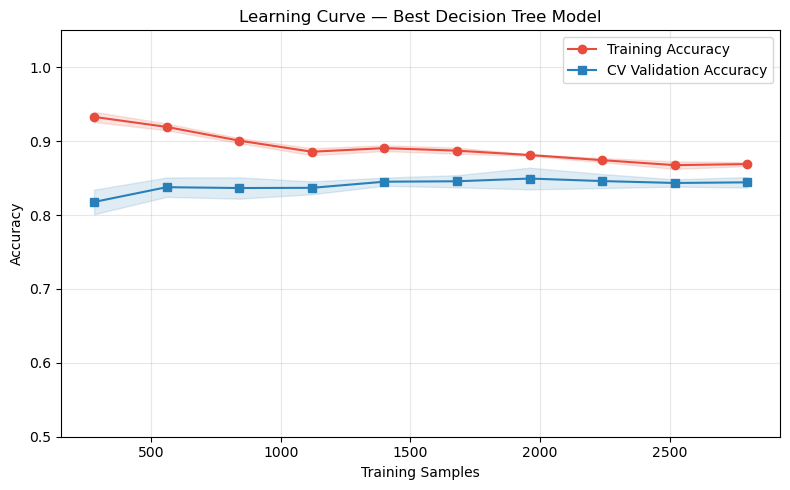

✓ 圖8 儲存完成
最終訓練 Accuracy: 0.8690 ± 0.0028
最終 CV Accuracy:  0.8443 ± 0.0071


In [19]:
# ── 圖8：學習曲線 ────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_tree, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#e74c3c', label='Training Accuracy')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, va_mean, 's-', color='#2980b9', label='CV Validation Accuracy')
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color='#2980b9')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Best Decision Tree Model')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
fig.savefig(FIG_DIR / '08_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ 圖8 儲存完成")
print(f"最終訓練 Accuracy: {tr_mean[-1]:.4f} ± {tr_std[-1]:.4f}")
print(f"最終 CV Accuracy:  {va_mean[-1]:.4f} ± {va_std[-1]:.4f}")


In [20]:
# ── 儲存最佳模型 ─────────────────────────────────────────────
joblib.dump(best_tree, MODEL_DIR / 'best_decision_tree.pkl')
print(f"✓ 最佳模型已儲存: {MODEL_DIR / 'best_decision_tree.pkl'}")

# ── 輸出結果摘要 ─────────────────────────────────────────────
print("\n" + "="*55)
print("           實驗結果摘要")
print("="*55)
print(f"  資料集    : 心臟病預測 (n={len(df)}, features=13)")
print(f"  訓練/測試 : {len(X_train)} / {len(X_test)} 筆")
print(f"  最佳參數  : {grid_search.best_params_}")
print(f"  樹深度    : {best_tree.get_depth()}  葉節點數: {best_tree.get_n_leaves()}")
print(f"  訓練 Acc  : {acc_best_train:.4f}")
print(f"  測試 Acc  : {acc_best_test:.4f}")
print(f"  ROC-AUC   : {auc_best:.4f}")
print(f"  輸出目錄  : {OUTPUT_DIR}")
print("="*55)


✓ 最佳模型已儲存: d:\MyGit\ChemE-3590\Part_3\Unit11\outputs\P3_Unit11_Example01_Heart_Disease\models\best_decision_tree.pkl

           實驗結果摘要
  資料集    : 心臟病預測 (n=5000, features=13)
  訓練/測試 : 3500 / 1500 筆
  最佳參數  : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
  樹深度    : 5  葉節點數: 31
  訓練 Acc  : 0.8643
  測試 Acc  : 0.8513
  ROC-AUC   : 0.9228
  輸出目錄  : d:\MyGit\ChemE-3590\Part_3\Unit11\outputs\P3_Unit11_Example01_Heart_Disease
